# AuraFitness Streak Insight Engine Testing

This notebook tests the rule-based streak insight engine.

Important:

- This is not ML training.
- Manual logs are controlled function tests only.
- No fake training dataset is used.
- Later, the React app will pass real localStorage user habit logs into this engine.

Engine tracks:

- workout streak
- water streak
- calorie goal streak
- fasting streak
- rest day discipline

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from utils.streak_insights import DailyUserLog, StreakInsightRequest, generate_streak_insights

REPORTS_DIR = AI_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai


## Controlled habit logs

These logs are used only to test function behavior.

They are not training data.

In [2]:
daily_logs = [
    DailyUserLog(
        log_date="2026-06-29",
        workout_completed=True,
        water_goal_met=True,
        calorie_goal_met=False,
        fasting_goal_met=True,
    ),
    DailyUserLog(
        log_date="2026-06-30",
        workout_completed=False,
        water_goal_met=True,
        calorie_goal_met=True,
        fasting_goal_met=True,
        planned_rest_day=True,
        rest_day_followed=True,
    ),
    DailyUserLog(
        log_date="2026-07-01",
        workout_completed=True,
        water_goal_met=True,
        calorie_goal_met=True,
        fasting_goal_met=False,
    ),
    DailyUserLog(
        log_date="2026-07-02",
        workout_completed=True,
        water_goal_met=True,
        calorie_goal_met=True,
        fasting_goal_met=True,
    ),
    DailyUserLog(
        log_date="2026-07-03",
        workout_completed=True,
        water_goal_met=True,
        calorie_goal_met=False,
        fasting_goal_met=True,
    ),
    DailyUserLog(
        log_date="2026-07-04",
        workout_completed=True,
        water_goal_met=True,
        calorie_goal_met=True,
        fasting_goal_met=True,
    ),
]

logs_df = pd.DataFrame([asdict(log) for log in daily_logs])
display(logs_df)

,log_date,workout_completed,water_goal_met,calorie_goal_met,fasting_goal_met,planned_rest_day,rest_day_followed
0,2026-06-29,True,True,False,True,False,False
1,2026-06-30,False,True,True,True,True,True
2,2026-07-01,True,True,True,False,False,False
3,2026-07-02,True,True,True,True,False,False
4,2026-07-03,True,True,False,True,False,False
5,2026-07-04,True,True,True,True,False,False


## Generate streak insights

This cell runs the rule-based streak insight engine.

In [3]:
request = StreakInsightRequest(
    today="2026-07-04",
    daily_logs=daily_logs,
    minimum_workout_days_per_week=3,
)

summary = generate_streak_insights(request)

rows = []

for name, result in [
    ("workout", summary.workout),
    ("water", summary.water),
    ("calorie", summary.calorie),
    ("fasting", summary.fasting),
    ("rest_day", summary.rest_day),
]:
    rows.append({
        "streak_name": name,
        **asdict(result),
    })

results_df = pd.DataFrame(rows)
display(results_df)

print("Overall score:", summary.overall_score)
print("Overall message:", summary.overall_message)

,streak_name,streak_type,current_streak,best_streak,completed_today,title,message,tone,confidence,reason_codes
0,workout,workout,4,4,True,Workout streak is strong,You are on a 4-day workout streak. This matche...,positive,0.85,"[active_streak, matched_or_beat_best_streak]"
1,water,water,6,6,True,Water streak is strong,You are on a 6-day water streak. This matches ...,positive,0.85,"[active_streak, matched_or_beat_best_streak]"
2,calorie,calorie,1,3,True,Calorie goal streak active,You are on a 1-day calorie goal streak. Keep i...,positive,0.85,[active_streak]
3,fasting,fasting,3,3,True,Fasting streak is strong,You are on a 3-day fasting streak. This matche...,positive,0.85,"[active_streak, matched_or_beat_best_streak]"
4,rest_day,rest_day,0,1,False,No rest day planned today,Rest day discipline will be tracked when a pla...,recovery,0.85,[no_rest_day_planned_today]


Overall score: 82
Overall message: Strong week. Your consistency is building momentum across training and habits.


## Chart current streaks

This chart shows current streak length by habit type.

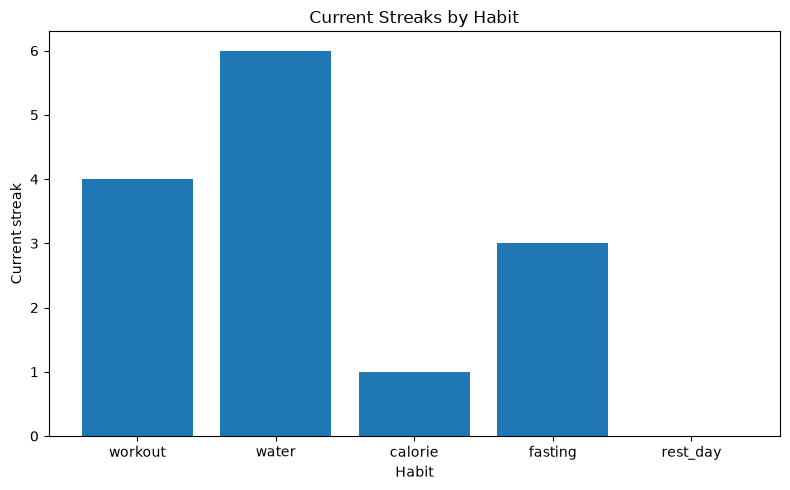

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\streak_insights_current_streaks.png


In [4]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["streak_name"], results_df["current_streak"])
plt.title("Current Streaks by Habit")
plt.xlabel("Habit")
plt.ylabel("Current streak")
plt.tight_layout()

output_path = FIGURES_DIR / "streak_insights_current_streaks.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart best streaks

This chart shows best streak length by habit type.

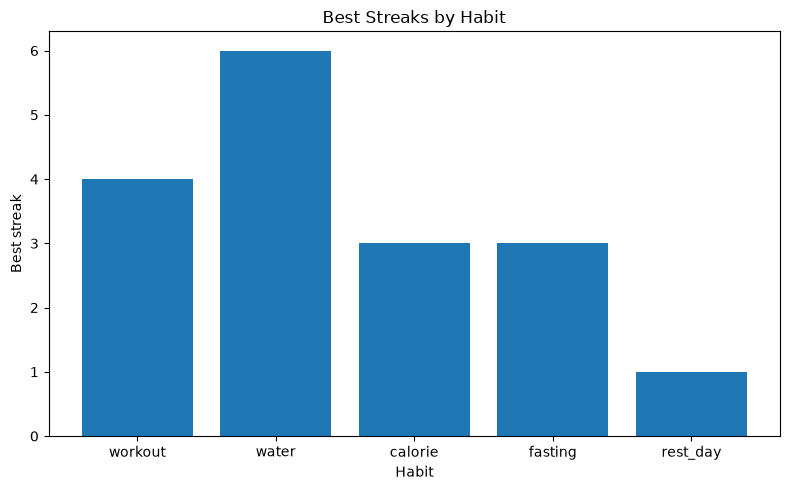

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\streak_insights_best_streaks.png


In [5]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["streak_name"], results_df["best_streak"])
plt.title("Best Streaks by Habit")
plt.xlabel("Habit")
plt.ylabel("Best streak")
plt.tight_layout()

output_path = FIGURES_DIR / "streak_insights_best_streaks.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart confidence values

This chart shows confidence for each streak insight.

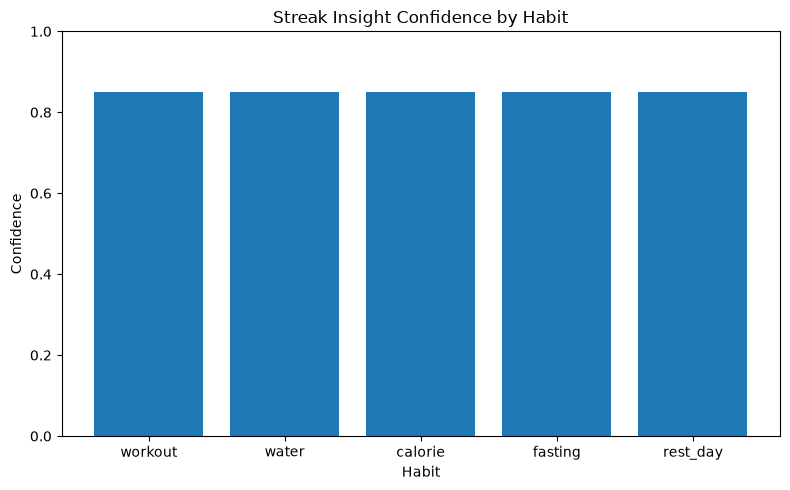

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\streak_insights_confidence.png


In [6]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["streak_name"], results_df["confidence"])
plt.title("Streak Insight Confidence by Habit")
plt.xlabel("Habit")
plt.ylabel("Confidence")
plt.ylim(0, 1)
plt.tight_layout()

output_path = FIGURES_DIR / "streak_insights_confidence.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Save streak insight test results

This saves the engine test result table for documentation.

In [7]:
output_path = REPORTS_DIR / "streak_insights_test_results.csv"
results_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\streak_insights_test_results.csv


## Behavior validation

This validates expected streak values for the controlled test logs.

In [8]:
expected_values = {
    "workout": 4,
    "water": 6,
    "calorie": 1,
    "fasting": 3,
    "rest_day": 0,
}

for streak_name, expected_streak in expected_values.items():
    row = results_df[results_df["streak_name"] == streak_name].iloc[0]
    actual_streak = row["current_streak"]

    if actual_streak != expected_streak:
        raise ValueError(
            f"Expected {streak_name} current streak {expected_streak}, got {actual_streak}"
        )

print("Streak behavior validation passed.")

Streak behavior validation passed.


## Rest day discipline message review

Rest day discipline should only ask the user to follow a rest day when today is actually planned as a rest day.

If today is not a planned rest day, the insight should explain that rest discipline will be tracked on planned rest days.

In [9]:
rest_day_row = results_df[results_df["streak_name"] == "rest_day"].iloc[0]

if rest_day_row["title"] != "No rest day planned today":
    raise ValueError(f"Unexpected rest day title: {rest_day_row['title']}")

if "no_rest_day_planned_today" not in rest_day_row["reason_codes"]:
    raise ValueError("Expected no_rest_day_planned_today reason code.")

print("Rest day discipline messaging check passed.")

Rest day discipline messaging check passed.
